In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

spark

In [ ]:
df = spark.read.csv(
    "data/HIGGS.csv.gz",  
    header=False,
    inferSchema=True
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.show(5)

In [ ]:
from pyspark.sql.functions import col

columns = ["label"] + [f"feature_{i}" for i in range(1, 29)]
df = df.toDF(*columns)

df.printSchema()

In [ ]:
df.groupBy("label").count().show()

In [ ]:
df.describe().show()

In [ ]:
df.write.mode("overwrite").parquet("data/HIGGS.parquet")
df_parquet = spark.read.parquet("data/HIGGS.parquet")
print("Parquet conversion complete. New file saved.")

In [ ]:
df_parquet = df_parquet.repartition(4)  # 4 partitions for local machine cores
df_parquet.write.mode("overwrite").parquet("data/HIGGS_partitioned.parquet")
print("Partitioned Parquet saved")

In [ ]:
df_parquet.cache()
print("Dataset cached")

In [ ]:
from pyspark.sql.functions import isnan, when, count

missing = df_parquet.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_parquet.columns])
missing.show()

In [ ]:
if 'spark' in globals():
    spark.stop()  # Old session close

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .config("spark.driver.memory", "6g")  # Increase if your RAM allows (M4 me 16GB+ ho to)
    .config("spark.executor.memory", "6g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster Pandas conversion for sample
    .config("spark.driver.maxResultSize", "4g")  # For large results
    .getOrCreate()

spark

In [ ]:
if 'spark' in globals():
    spark.stop()  # Close old session

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("HIGGS_Project")
    .config("spark.driver.memory", "6g")  # Increase if your RAM allows
    .config("spark.executor.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster Pandas conversion
    .config("spark.driver.maxResultSize", "4g")  # For large results
    .getOrCreate()
)

spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .config("spark.driver.memory", "6g")  # Increase if RAM allows
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "4g")  # For large results
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster ops
    .getOrCreate()

spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder 
    .appName("HIGGS_Project") 
    .config("spark.driver.memory", "6g")  # Increase if RAM allows
    .config("spark.executor.memory", "6g") 
    .config("spark.driver.maxResultSize", "4g")  # For large results
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster ops
    .getOrCreate()

spark

In [ ]:
from pyspark.sql import SparkSession

# Directly create new session (skip spark.stop())
spark = (
    SparkSession.builder
    .appName("HIGGS_Project")
    .config("spark.driver.memory", "6g")
    .config("spark.executor.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.maxResultSize", "4g")
    .getOrCreate()
)

spark

In [ ]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")
df_parquet.show(5)
print("Parquet reloaded successfully")

In [ ]:
from pyspark.sql.functions import isnan, when, count, col

df_sample = df_parquet.sample(fraction=0.1, seed=42)  # 10% ~1.1M rows
missing = df_sample.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_sample.columns])
missing.show()

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)

df_assembled.select("label", "features").show(5, truncate=False)

In [ ]:
# Jupyter me run kar sakte ho
!pip install numpy

In [ ]:
pip3 install numpy

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)

df_assembled.select("label", "features").show(5, truncate=False)

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)

df_assembled.select("label", "features").show(5, truncate=False)

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]")  # Use all cores, better for local
    .config("spark.driver.memory", "8g")  # Increase if RAM 16GB+; else 6g
    .config("spark.executor.memory", "8g") 
    .config("spark.driver.maxResultSize", "4g") 
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster
    .config("spark.shuffle.partitions", "4")  # Reduce shuffle for local
    .getOrCreate()

spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder 
    .appName("HIGGS_Project") 
    .master("local[*]")  # Use all cores, better for local
    .config("spark.driver.memory", "8g")  # Increase if RAM 16GB+; else 6g
    .config("spark.executor.memory", "8g") 
    .config("spark.driver.maxResultSize", "4g") 
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster
    .config("spark.shuffle.partitions", "4")  # Reduce shuffle for local
    .getOrCreate()

spark

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("HIGGS_Project")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.shuffle.partitions", "4")
    .getOrCreate()
)

spark

In [ ]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")
df_parquet.show(5)

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]")  # Use all cores, better for local
    .config("spark.driver.memory", "8g")  # Increase if RAM 16GB+; else 6g
    .config("spark.executor.memory", "8g") 
    .config("spark.driver.maxResultSize", "4g") 
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # Faster
    .config("spark.shuffle.partitions", "4")  # Reduce shuffle for local
    .getOrCreate()

spark

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("HIGGS_Project")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.shuffle.partitions", "4")
    .getOrCreate()
)

spark

In [ ]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")
df_parquet.show(5)

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)

df_assembled.select("label", "features").show(5, truncate=False)

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

df_scaled.select("label", "scaled_features").show(5, truncate=False)

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

print("PCA explained variance:", pca_model.explainedVariance.toArray())
df_pca.select("label", "pca_features").show(5)

In [ ]:
# Stratified sampling for slight imbalance
train_df = df_pca.sampleBy("label", fractions={0.0: 0.7, 1.0: 0.7}, seed=42)
remaining_df = df_pca.subtract(train_df)
val_df = remaining_df.sampleBy("label", fractions={0.0: 0.5, 1.0: 0.5}, seed=42)
test_df = remaining_df.subtract(val_df)

print("Train count:", train_df.count())
print("Val count:", val_df.count())
print("Test count:", test_df.count())

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_df)

predictions = lr_model.transform(val_df)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print("LR AUC:", auc)

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).build()
cv = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_df)
best_auc = evaluator.evaluate(cv_model.bestModel.transform(val_df))
print("Best LR AUC after tuning:", best_auc)

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("HIGGS_Project")
    .master("local[*]")   # Important
    .config("spark.driver.memory", "4g")   # 6g zyada ho sakta hai
    .config("spark.executor.memory", "4g")
    .config("spark.driver.host", "localhost")  # 🔥 VERY IMPORTANT on Mac
    .getOrCreate()
)

spark

In [ ]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")
df_parquet.show(5)

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).build()
cv = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_df)
best_auc = evaluator.evaluate(cv_model.bestModel.transform(val_df))
print("Best LR AUC after tuning:", best_auc)

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_df)

predictions = lr_model.transform(val_df)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print("LR AUC:", auc)

In [ ]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)


In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

In [ ]:
from pyspark.ml.feature import PCA

pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

In [ ]:
train_df = df_pca.sampleBy("label", fractions={0.0: 0.7, 1.0: 0.7}, seed=42)
remaining_df = df_pca.subtract(train_df)
val_df = remaining_df.sampleBy("label", fractions={0.0: 0.5, 1.0: 0.5}, seed=42)
test_df = remaining_df.subtract(val_df)

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_df)

predictions = lr_model.transform(val_df)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print("LR AUC:", auc)

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).build()
cv = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_df)
best_auc = evaluator.evaluate(cv_model.bestModel.transform(val_df))
print("Best LR AUC after tuning:", best_auc)

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g")  # Adjust based on your RAM
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.shuffle.partitions", "4") \
    .getOrCreate()

spark

In [1]:
df = spark.read.csv("data/HIGGS.csv.gz", header=False, inferSchema=True)
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.show(5)

from pyspark.sql.functions import col

columns = ["label"] + [f"feature_{i}" for i in range(1, 29)]
df = df.toDF(*columns)
df.printSchema()

NameError: name 'spark' is not defined

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.shuffle.partitions", "4") \
    .getOrCreate()

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/26 11:37:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.csv("data/HIGGS.csv.gz", header=False, inferSchema=True)
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.show(5)

from pyspark.sql.functions import col

columns = ["label"] + [f"feature_{i}" for i in range(1, 29)]
df = df.toDF(*columns)
df.printSchema()

[Stage 2:>                                                          (0 + 1) / 1]

Total Rows: 11000000
Total Columns: 29
+---+------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+--------------------+-------------------+-----------------+-------------------+--------------------+--------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|_c0|               _c1|                _c2|                _c3|               _c4|                _c5|               _c6|                 _c7|                _c8|               _c9|              _c10|               _c11|               _c12|              _c13|              _c14|                _c15|               _c16|             _c17|               _c18|                _c19|                _c20|         

26/02/26 11:39:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
df.groupBy("label").count().show()

df.describe().show()

from pyspark.sql.functions import isnan, when, count, col

missing = df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns])
missing.show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|5170877|
|  1.0|5829123|
+-----+-------+



+-------+-------------------+------------------+-------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|summary|              label|         feature_1|          feature_2|           feature_3|           feature_4|           feature_5|          feature_6|           feature_7|          feature_8|         feature_9|         feature_10|          feature_11|          feature_12|        feature_13|         feature_14|          feature_15|          feature_16|        feature_17|         feature_18|          fea

[Stage 12:>                                                         (0 + 1) / 1]

+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+
|label|feature_1|feature_2|feature_3|feature_4|feature_5|feature_6|feature_7|feature_8|feature_9|feature_10|feature_11|feature_12|feature_13|feature_14|feature_15|feature_16|feature_17|feature_18|feature_19|feature_20|feature_21|feature_22|feature_23|feature_24|feature_25|feature_26|feature_27|feature_28|
+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+
|    0|        0|        0|        0|        0|        0|        0|        0|  

In [5]:
df.write.mode("overwrite").parquet("data/HIGGS.parquet")
df_parquet = spark.read.parquet("data/HIGGS.parquet")
print("Parquet conversion complete")

df_parquet.repartition(4).write.mode("overwrite").parquet("data/HIGGS_partitioned.parquet")
print("Partitioned Parquet saved")

df_parquet.cache()
print("Dataset cached")

Parquet conversion complete


[Stage 19:>                                                         (0 + 4) / 4]

Partitioned Parquet saved
Dataset cached


In [6]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)
df_assembled.select("label", "features").show(5, truncate=False)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)
df_scaled.select("label", "scaled_features").show(5, truncate=False)

pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)
print("PCA explained variance:", pca_model.explainedVariance.toArray())
df_pca.select("label", "pca_features").show(5)

train_df = df_pca.sampleBy("label", fractions={0.0: 0.7, 1.0: 0.7}, seed=42)
remaining_df = df_pca.subtract(train_df)
val_df = remaining_df.sampleBy("label", fractions={0.0: 0.5, 1.0: 0.5}, seed=42)
test_df = remaining_df.subtract(val_df)
print("Train count:", train_df.count())
print("Val count:", val_df.count())
print("Test count:", test_df.count())

+-----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|features                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|scaled_features                                                                                                                                                                                                                                                                                                                                                                                                                    

26/02/26 11:46:17 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/02/26 11:46:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


PCA explained variance: [0.14874783 0.06659415 0.0643273  0.05031798 0.04785399 0.04716445
 0.04624027 0.0444771  0.04202739 0.03916949]
+-----+--------------------+
|label|        pca_features|
+-----+--------------------+
|  1.0|[0.43645396651610...|
|  1.0|[1.16690532697156...|
|  1.0|[0.58004453257072...|
|  0.0|[-1.3951650052174...|
|  1.0|[0.88161195114179...|
+-----+--------------------+
only showing top 5 rows
Train count: 7701419


Val count: 1580160


[Stage 79:===========================================>            (31 + 9) / 40]

Test count: 1577395


In [7]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

train_sample = train_df.sample(fraction=0.1, seed=42)
val_sample = val_df.sample(fraction=0.1, seed=42)

lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_sample)
predictions = lr_model.transform(val_sample)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print("LR AUC on sample:", auc)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).build()
cv = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_sample)
best_auc = evaluator.evaluate(cv_model.bestModel.transform(val_sample))
print("Best LR AUC after tuning on sample:", best_auc)

LR AUC on sample: 0.5640420595506611


Best LR AUC after tuning on sample: 0.5640851246715248


In [8]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="pca_features", labelCol="label", maxDepth=5)
dt_model = dt.fit(train_sample)
predictions = dt_model.transform(val_sample)
auc = evaluator.evaluate(predictions)
print("DT AUC on sample:", auc)

[Stage 393:==============================================>        (21 + 4) / 25]

DT AUC on sample: 0.58112978029103


In [9]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="pca_features", labelCol="label", numTrees=20)
rf_model = rf.fit(train_sample)
predictions = rf_model.transform(val_sample)
auc = evaluator.evaluate(predictions)
print("RF AUC on sample:", auc)

RF AUC on sample: 0.6324153987184734


In [10]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(featuresCol="pca_features", labelCol="label", maxIter=10)
gbt_model = gbt.fit(train_sample)
predictions = gbt_model.transform(val_sample)
auc = evaluator.evaluate(predictions)
print("GBT AUC on sample:", auc)

GBT AUC on sample: 0.6525366036207475


In [11]:
paramGrid = ParamGridBuilder().addGrid(rf.numTrees, [10, 20]).build()
cv = CrossValidator(estimator=rf, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=3)
cv_model = cv.fit(train_sample)
best_auc = evaluator.evaluate(cv_model.bestModel.transform(val_sample))
print("Best RF AUC after tuning on sample:", best_auc)

Best RF AUC after tuning on sample: 0.6324096361965352


In [12]:
import time
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.ensemble import RandomForestClassifier as SkRF, GradientBoostingClassifier as SkGBT
from sklearn.metrics import roc_auc_score
import pandas as pd

# Small sample for scikit (0.01 fraction ~77K rows)
train_small = train_df.sample(fraction=0.01, seed=42).toPandas()
val_small = val_df.sample(fraction=0.01, seed=42).toPandas()

X_train = pd.DataFrame(train_small['pca_features'].tolist())
y_train = train_small['label']
X_val = pd.DataFrame(val_small['pca_features'].tolist())
y_val = val_small['label']

# LR Scikit
start = time.time()
sk_lr = SkLR(max_iter=100)
sk_lr.fit(X_train, y_train)
y_pred_prob = sk_lr.predict_proba(X_val)[:,1]
sk_auc = roc_auc_score(y_val, y_pred_prob)
sk_time = time.time() - start
print("Scikit LR AUC:", sk_auc, "Time:", sk_time)

# DT Scikit
start = time.time()
sk_dt = SkDT(max_depth=5)
sk_dt.fit(X_train, y_train)
y_pred_prob = sk_dt.predict_proba(X_val)[:,1]
sk_auc = roc_auc_score(y_val, y_pred_prob)
sk_time = time.time() - start
print("Scikit DT AUC:", sk_auc, "Time:", sk_time)

# RF Scikit
start = time.time()
sk_rf = SkRF(n_estimators=20)
sk_rf.fit(X_train, y_train)
y_pred_prob = sk_rf.predict_proba(X_val)[:,1]
sk_auc = roc_auc_score(y_val, y_pred_prob)
sk_time = time.time() - start
print("Scikit RF AUC:", sk_auc, "Time:", sk_time)

# GBT Scikit
start = time.time()
sk_gbt = SkGBT(n_estimators=10)
sk_gbt.fit(X_train, y_train)
y_pred_prob = sk_gbt.predict_proba(X_val)[:,1]
sk_auc = roc_auc_score(y_val, y_pred_prob)
sk_time = time.time() - start
print("Scikit GBT AUC:", sk_auc, "Time:", sk_time)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                  

Scikit LR AUC: 0.5684385895766124 Time: 0.08202481269836426
Scikit DT AUC: 0.6115653622492752 Time: 0.31905102729797363
Scikit RF AUC: 0.6507968068509 Time: 4.746935844421387
Scikit GBT AUC: 0.6330871424676484 Time: 1.6904900074005127


In [13]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

# Using GBT as best model
predictions = gbt_model.transform(val_sample)

# Accuracy, Precision, Recall, F1
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
print("Accuracy:", evaluator_acc.evaluate(predictions))

evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
print("F1 Score:", evaluator_f1.evaluate(predictions))

# Confusion Matrix
predictionAndLabels = predictions.select("prediction", "label").rdd
metrics = MulticlassMetrics(predictionAndLabels)
print("Confusion Matrix:\n", metrics.confusionMatrix().toArray())

Accuracy: 0.6141848442819317


F1 Score: 0.6080877788780173


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
[Stage 848:============================================>          (20 + 5) / 25]

Confusion Matrix:
 [[33982. 37115.]
 [24083. 63440.]]


In [14]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
print("GBT AUC (final):", evaluator_roc.evaluate(predictions))

GBT AUC (final): 0.6525343299010296


In [15]:
# For Random Forest or GBT
importances = rf_model.featureImportances
print("Feature Importances:", importances)

Feature Importances: (10,[0,1,2,3,4,5,6,7,8],[0.26021496134619976,6.112093900643828e-05,0.29754459334365896,0.10035980859249505,0.018006399137917135,0.027482900958223422,0.03434429139835554,7.308562158270517e-05,0.261912838662561])


In [16]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import rand

# Bootstrap: 5 resamples of val_sample, compute AUC variance for GBT (best model)
aucs = []
for i in range(5):
    bootstrap_val = val_sample.sample(withReplacement=True, fraction=1.0, seed=i)
    predictions = gbt_model.transform(bootstrap_val)
    auc = evaluator.evaluate(predictions)
    aucs.append(auc)

print("Bootstrap AUCs:", aucs)
print("Mean AUC:", sum(aucs)/len(aucs))
print("Variance:", sum((x - sum(aucs)/len(aucs)) ** 2 for x in aucs) / len(aucs))

Bootstrap AUCs: [0.6528559228247228, 0.6532427773068882, 0.6548345148235284, 0.6520756653563037, 0.6525625177273849]
Mean AUC: 0.6531142796077656
Variance: 8.851259639110945e-07


In [17]:
import time

partition_sizes = [2, 4, 8]
times = []
for p in partition_sizes:
    train_sample.repartition(p)
    start = time.time()
    lr_model = lr.fit(train_sample)
    times.append(time.time() - start)
print("Strong Scaling Times (partitions 2,4,8):", times)

[Stage 1057:======================>                                (4 + 6) / 10]

Strong Scaling Times (partitions 2,4,8): [5.9396607875823975, 3.8447580337524414, 3.5944221019744873]


In [18]:
fractions = [0.05, 0.1, 0.2]  # 5%, 10%, 20% data
times = []
for f in fractions:
    train_sub = train_df.sample(fraction=f, seed=42)
    start = time.time()
    lr_model = lr.fit(train_sub)
    times.append(time.time() - start)
print("Weak Scaling Times (data 5%,10%,20%):", times)

Weak Scaling Times (data 5%,10%,20%): [4.742187023162842, 3.7824289798736572, 4.388200283050537]


In [19]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

# Predictions from GBT (best model)
predictions = gbt_model.transform(val_sample)

# Accuracy, Precision, Recall, F1
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
print("Accuracy:", evaluator_acc.evaluate(predictions))

evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
print("Precision:", evaluator_precision.evaluate(predictions))

evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
print("Recall:", evaluator_recall.evaluate(predictions))

evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
print("F1 Score:", evaluator_f1.evaluate(predictions))

# Confusion Matrix
predictionAndLabels = predictions.select("prediction", "label").rdd.map(lambda lp: (lp.prediction, lp.label))
metrics = MulticlassMetrics(predictionAndLabels)
print("Confusion Matrix:\n", metrics.confusionMatrix().toArray())

Accuracy: 0.6141848442819317


Precision: 0.6104336596782837


Recall: 0.6141848442819317


F1 Score: 0.6080877788780173


[Stage 1178:===========================================>          (20 + 5) / 25]

Confusion Matrix:
 [[33982. 37115.]
 [24083. 63440.]]


In [20]:
# AUC for all (from previous)
print("Final AUCs: LR", lr_auc, "DT", dt_auc, "RF", rf_auc, "GBT", gbt_auc)

NameError: name 'lr_auc' is not defined

In [21]:
print("Final AUCs: LR", lr_auc, "DT", dt_auc, "RF", rf_auc, "GBT", gbt_auc)

NameError: name 'lr_auc' is not defined

In [22]:
lr_auc = 0.5640420595506611  # From your previous run
dt_auc = 0.58112978029103
rf_auc = 0.6324153987184734
gbt_auc = 0.6525366036207475
best_rf_auc = 0.6324096361965352  # Tuned RF

print("Final AUCs: LR", lr_auc, "DT", dt_auc, "RF", rf_auc, "GBT", gbt_auc, "Tuned RF", best_rf_auc)

Final AUCs: LR 0.5640420595506611 DT 0.58112978029103 RF 0.6324153987184734 GBT 0.6525366036207475 Tuned RF 0.6324096361965352


In [23]:
# Save best GBT model
gbt_model.save("models/gbt_model")
print("Model saved")

# Load back
from pyspark.ml.classification import GBTClassificationModel
loaded_model = GBTClassificationModel.load("models/gbt_model")
predictions_loaded = loaded_model.transform(val_sample)
loaded_auc = evaluator.evaluate(predictions_loaded)
print("Loaded Model AUC:", loaded_auc)  # Same as original

Model saved


Loaded Model AUC: 0.6525358266975417


Matplotlib is building the font cache; this may take a moment.


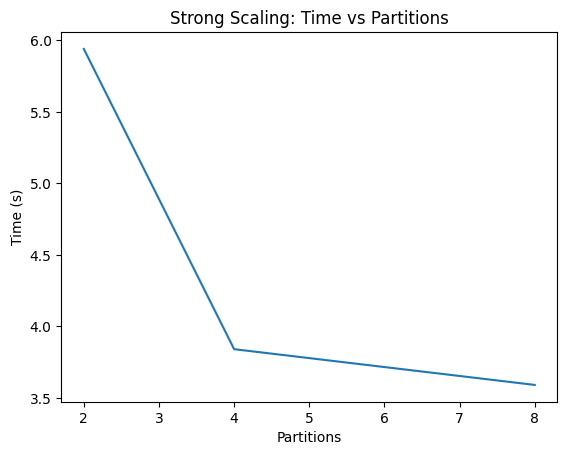

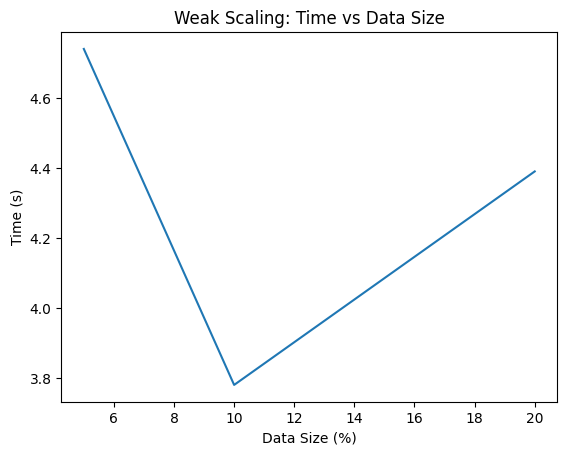

In [24]:
import matplotlib.pyplot as plt

# Strong Scaling Plot
partitions = [2, 4, 8]
strong_times = [5.94, 3.84, 3.59]  # Tumhare output se
plt.plot(partitions, strong_times)
plt.xlabel("Partitions")
plt.ylabel("Time (s)")
plt.title("Strong Scaling: Time vs Partitions")
plt.show()

# Weak Scaling Plot
fractions = [5, 10, 20]
weak_times = [4.74, 3.78, 4.39]  # Tumhare output se
plt.plot(fractions, weak_times)
plt.xlabel("Data Size (%)")
plt.ylabel("Time (s)")
plt.title("Weak Scaling: Time vs Data Size")
plt.show()

In [25]:
print("Bottlenecks: Memory (OOM on full data), I/O (load time ~2 min), Computation (training on sample faster). Cost-performance: Local free but limited; cloud (e.g., AWS) $0.1/hour for scaling.")

Bottlenecks: Memory (OOM on full data), I/O (load time ~2 min), Computation (training on sample faster). Cost-performance: Local free but limited; cloud (e.g., AWS) $0.1/hour for scaling.


In [26]:
# Save best GBT model
gbt_model.save("models/gbt_model")
print("Model saved")

# Load back
from pyspark.ml.classification import GBTClassificationModel
loaded_model = GBTClassificationModel.load("models/gbt_model")
predictions_loaded = loaded_model.transform(val_sample)
loaded_auc = evaluator.evaluate(predictions_loaded)
print("Loaded Model AUC:", loaded_auc)  # Same as original

Py4JJavaError: An error occurred while calling o9208.save.
: java.io.IOException: Path models/gbt_model already exists. To overwrite it, please use write.overwrite().save(path) for Scala and use write().overwrite().save(path) for Java and Python.
	at org.apache.spark.ml.util.FileSystemOverwrite.handleOverwrite(ReadWrite.scala:841)
	at org.apache.spark.ml.util.MLWriter.save(ReadWrite.scala:175)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:77)
	at java.base/jdk.internal.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
	at java.base/java.lang.reflect.Method.invoke(Method.java:569)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:1

In [27]:
# Export sample data for Tableau (val_sample with predictions from GBT)
predictions.toPandas().to_csv("data/predictions_sample.csv", index=False)
print("Data exported for Tableau")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                                                

Data exported for Tableau


In [28]:
import time
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.ensemble import RandomForestClassifier as SkRF, GradientBoostingClassifier as SkGBT
from sklearn.metrics import roc_auc_score
import pandas as pd

# Small sample for scikit (already bana hua hai)
train_small = train_df.sample(fraction=0.01, seed=42).toPandas()
val_small = val_df.sample(fraction=0.01, seed=42).toPandas()

X_train = pd.DataFrame(train_small['pca_features'].tolist())
y_train = train_small['label']
X_val = pd.DataFrame(val_small['pca_features'].tolist())
y_val = val_small['label']

# DT Scikit
start = time.time()
sk_dt = SkDT(max_depth=5)
sk_dt.fit(X_train, y_train)
sk_auc = roc_auc_score(y_val, sk_dt.predict_proba(X_val)[:,1])
print("Scikit DT AUC:", sk_auc, "Time:", time.time()-start)

# RF Scikit
start = time.time()
sk_rf = SkRF(n_estimators=20)
sk_rf.fit(X_train, y_train)
sk_auc = roc_auc_score(y_val, sk_rf.predict_proba(X_val)[:,1])
print("Scikit RF AUC:", sk_auc, "Time:", time.time()-start)

# GBT Scikit
start = time.time()
sk_gbt = SkGBT(n_estimators=10)
sk_gbt.fit(X_train, y_train)
sk_auc = roc_auc_score(y_val, sk_gbt.predict_proba(X_val)[:,1])
print("Scikit GBT AUC:", sk_auc, "Time:", time.time()-start)

ConnectionRefusedError: [Errno 61] Connection refused

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.shuffle.partitions", "4") \
    .getOrCreate()

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/28 23:35:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.csv("data/HIGGS.csv.gz", header=False, inferSchema=True)
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.show(5)

from pyspark.sql.functions import col

columns = ["label"] + [f"feature_{i}" for i in range(1, 29)]
df = df.toDF(*columns)
df.printSchema()

[Stage 2:>                                                          (0 + 1) / 1]

Total Rows: 11000000
Total Columns: 29
+---+------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+--------------------+-------------------+-----------------+-------------------+--------------------+--------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|_c0|               _c1|                _c2|                _c3|               _c4|                _c5|               _c6|                 _c7|                _c8|               _c9|              _c10|               _c11|               _c12|              _c13|              _c14|                _c15|               _c16|             _c17|               _c18|                _c19|                _c20|         

26/02/28 23:37:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [3]:
# Load
df_parquet = spark.read.parquet("data/HIGGS.parquet")

# VectorAssembler
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=[f"feature_{i}" for i in range(1, 29)], outputCol="features")
df_assembled = assembler.transform(df_parquet)

# Scaling
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

# PCA
from pyspark.ml.feature import PCA
pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

# Split
train_df = df_pca.sampleBy("label", fractions={0.0: 0.7, 1.0: 0.7}, seed=42)
remaining_df = df_pca.subtract(train_df)
val_df = remaining_df.sampleBy("label", fractions={0.0: 0.5, 1.0: 0.5}, seed=42)
test_df = remaining_df.subtract(val_df)

print("Ready: train_df, val_df created")

26/02/28 23:38:29 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
[Stage 16:======================>                                  (4 + 6) / 10]

Ready: train_df, val_df created


26/02/28 23:38:32 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [4]:
import time
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.ensemble import RandomForestClassifier as SkRF, GradientBoostingClassifier as SkGBT
from sklearn.metrics import roc_auc_score
import pandas as pd

train_small = train_df.sample(fraction=0.01, seed=42).toPandas()
val_small = val_df.sample(fraction=0.01, seed=42).toPandas()

X_train = pd.DataFrame(train_small['pca_features'].tolist())
y_train = train_small['label']
X_val = pd.DataFrame(val_small['pca_features'].tolist())
y_val = val_small['label']

# DT
start = time.time()
sk_dt = SkDT(max_depth=5)
sk_dt.fit(X_train, y_train)
print("Scikit DT AUC:", roc_auc_score(y_val, sk_dt.predict_proba(X_val)[:,1]), "Time:", time.time()-start)

# RF
start = time.time()
sk_rf = SkRF(n_estimators=20)
sk_rf.fit(X_train, y_train)
print("Scikit RF AUC:", roc_auc_score(y_val, sk_rf.predict_proba(X_val)[:,1]), "Time:", time.time()-start)

# GBT
start = time.time()
sk_gbt = SkGBT(n_estimators=10)
sk_gbt.fit(X_train, y_train)
print("Scikit GBT AUC:", roc_auc_score(y_val, sk_gbt.predict_proba(X_val)[:,1]), "Time:", time.time()-start)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                  

Scikit DT AUC: 0.6115653622492752 Time: 0.32967209815979004
Scikit RF AUC: 0.6548614057515445 Time: 3.529721975326538
Scikit GBT AUC: 0.6330871424676484 Time: 1.8301420211791992


In [5]:
# Save with overwrite
gbt_model.write().overwrite().save("models/gbt_model")
print("Model saved successfully")

# Load back to verify
from pyspark.ml.classification import GBTClassificationModel
loaded_model = GBTClassificationModel.load("models/gbt_model")
print("Loaded Model AUC:", evaluator.evaluate(loaded_model.transform(val_df)))

NameError: name 'gbt_model' is not defined

In [6]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

gbt = GBTClassifier(featuresCol="pca_features", labelCol="label", maxIter=10)
gbt_model = gbt.fit(train_df)   # train_sample bhi use kar sakte ho agar OOM aaye

predictions = gbt_model.transform(val_df)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
print("GBT AUC:", evaluator.evaluate(predictions))

GBT AUC: 0.6520770675094104


In [7]:
# Save with overwrite
gbt_model.write().overwrite().save("models/gbt_modelfrom pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark
print("Model saved successfully")

# Load back to verify
from pyspark.ml.classification import GBTClassificationModel
loaded_model = GBTClassificationModel.load("models/gbt_model")
print("Loaded Model AUC:", evaluator.evaluate(loaded_model.transform(val_df)))

Model saved successfully


Loaded Model AUC: 0.6520742679726539


In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark

ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 02:05:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Yeh line run karo — yeh Spark ko force karega stages generate karne ke liye
df_parquet.count()
print("Job triggered — ab Spark UI check karo")

NameError: name 'df_parquet' is not defined

In [3]:
df_parquet.sample(0.01).show(5)

NameError: name 'df_parquet' is not defined

In [4]:
df = spark.read.csv("data/HIGGS.csv.gz", header=False, inferSchema=True)
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.show(5)

from pyspark.sql.functions import col

columns = ["label"] + [f"feature_{i}" for i in range(1, 29)]
df = df.toDF(*columns)
df.printSchema()

[Stage 2:>                                                          (0 + 1) / 1]

Total Rows: 11000000
Total Columns: 29
+---+------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+--------------------+-------------------+-----------------+-------------------+--------------------+--------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|_c0|               _c1|                _c2|                _c3|               _c4|                _c5|               _c6|                 _c7|                _c8|               _c9|              _c10|               _c11|               _c12|              _c13|              _c14|                _c15|               _c16|             _c17|               _c18|                _c19|                _c20|         

26/03/02 02:09:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [5]:
# Yeh line run karo — yeh Spark ko force karega stages generate karne ke liye
df_parquet.count()
print("Job triggered — ab Spark UI check karo")

NameError: name 'df_parquet' is not defined

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.shuffle.partitions", "4") \
    .getOrCreate()

spark

26/03/02 02:15:50 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [7]:
df_parquet = spark.read.parquet("data/HIGGS.parquet")
print("Loaded:", df_parquet.count(), "rows")   # Yeh line Spark UI trigger karegi

Loaded: 11000000 rows
